# Exercise 10 — CNNs for image classification

## Learning objectives

After this lecture you should be able to:

1. **Compute** the output spatial size of any conv/pool layer given input size, kernel, stride, padding.
2. **Choose** between `same` and `valid` padding, and between strided convolution and pooling, and explain the trade-offs.
3. **Read** a CNN architecture and predict each layer's output shape on paper.
4. **Build** a small CNN classifier in Keras for a small image-classification task.


## Setup

In [1]:
import os, random
import numpy as np
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 780.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow: 2.21.0
GPU available: False


---

## 1 Why CNNs, why CIFAR-10

### What problem are we solving?

We want to look at a 32×32 colour image and decide which of 10 categories it shows: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, or truck. This is **CIFAR-10** — a classic benchmark with 60 000 labelled images.

### Why a CNN, not a dense network?

A 32×32 RGB image has 3072 pixel values. A dense layer that maps those to (say) 256 hidden units already needs ~786 000 parameters — and treats every pixel as independent, throwing away spatial structure. Two pixels that are next to each other in the image are no closer in the input vector than two pixels at opposite corners.

A CNN exploits two facts about images:

1. **Locality** — useful patterns (edges, textures, parts) are local. A 3×3 kernel can detect them and, by being applied at every position, share its weights across the whole image.
2. **Hierarchy** — small patterns combine into bigger ones. Edges → textures → parts → objects. Stacking conv layers naturally builds this hierarchy.

### Why CIFAR-10

Three properties make CIFAR-10 ideal for studying CNN building blocks:

| Property | Why it helps |
|---|---|
| 32×32 spatial size | $32 = 2^5$, so halving the spatial dimension a few times gives clean integers: 32 → 16 → 8 → 4. |
| RGB input | 3 input channels means the "channel growth" pattern (3 → 32 → 64 → 128) starts naturally. |
| Real natural images | Distinguishing a cat from a dog needs hierarchical features — exactly what stacked convs build. |
| 50 000 training images | Enough data to train a small CNN to ~75% accuracy in minutes on a GPU. |


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train: (50000, 32, 32, 3)   Val: (5000, 32, 32, 3)   Test: (5000, 32, 32, 3)


/tmp/ipykernel_1799/385132752.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.imshow(train_images[idx]); ax.set_title(class_names[int(train_labels[idx])], fontsize=10)


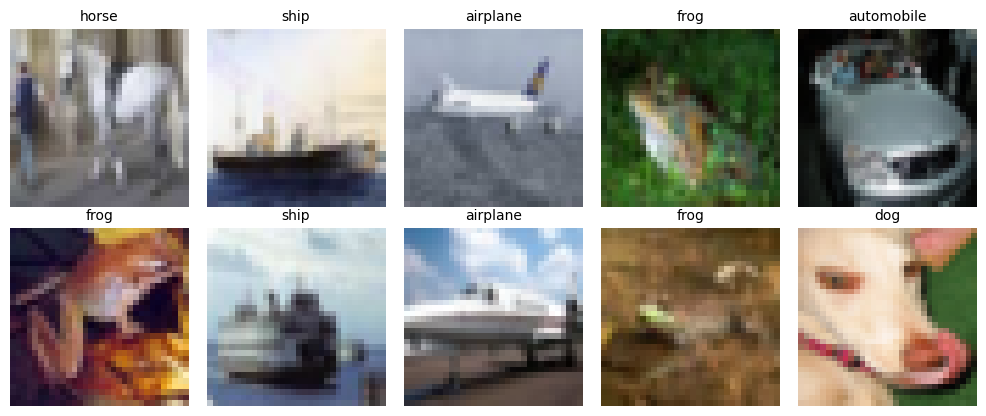

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images = train_images.astype('float32') / 255.0
test_images  = test_images.astype('float32') / 255.0

# Carve a 5k validation set out of the 10k test set so test stays untouched until the end
val_images, test_images, val_labels, test_labels = train_test_split(
    test_images, test_labels, test_size=0.5, random_state=SEED, stratify=test_labels
)

class_names = ['airplane','automobile','bird','cat','deer','dog',
               'frog','horse','ship','truck']

print(f'Train: {train_images.shape}   Val: {val_images.shape}   Test: {test_images.shape}')

# Quick visual: 10 random training images
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for ax, idx in zip(axes.flat, np.random.choice(len(train_images), 10, replace=False)):
    ax.imshow(train_images[idx]); ax.set_title(class_names[int(train_labels[idx])], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


---

## 2 Kernel, stride, padding

### The convolution

A convolutional layer slides a small **kernel** (a matrix of learnable weights, e.g. 3×3) across the input. At every position it computes a weighted sum of the pixels under the kernel and emits one output value.

A 2D conv layer takes an input of shape $(H, W, C_{in})$ and produces an output of shape $(H', W', C_{out})$. There are $C_{out}$ separate kernels, each of shape $(K, K, C_{in})$ — so each output channel is a different learned feature detector.

Three knobs control how the kernel slides:

- **Kernel size $K$** — how big a patch the kernel looks at. Standard choices: 3, 5, 7.
- **Stride $S$** — how far the kernel jumps between applications. $S=1$ means every pixel; $S=2$ means every other pixel.
- **Padding $P$** — zeros added around the input so the kernel can reach the edges.

### The dimension formula

For each spatial dimension (height or width) the output size is:

$$\boxed{\;H' \;=\; \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1\;}$$


### The two named padding modes

Keras gives you two named modes that pick $P$ for you:

**`padding='valid'`** — no padding ($P = 0$). The kernel only sits where it fits entirely inside the input.

- With $S = 1$: output shrinks by exactly $K - 1$ each layer. Stack 6 valid 3×3 convs on a 32×32 input and you get 20×20.
- With $S > 1$: $H' = \lfloor (H - K) / S \rfloor + 1$ — divisive, plus floor drops edge pixels that don't divide cleanly.

**`padding='same'`** — Keras picks $P$ so that with $S = 1$, output size = input size. For an odd kernel of size $K$, that's $P = (K - 1) / 2$:

- Kernel 3 → $P = 1$
- Kernel 5 → $P = 2$
- Kernel 7 → $P = 3$

With $S > 1$ and `same` padding: $H' = \lceil H / S \rceil$ — clean halving (or thirding, etc.).

### Why `same` is the default in modern CNNs

1. **Stackability** — you can pile up 50 stride-1 convs without spatial dimensions running out.
2. **Predictable arithmetic** — every layer's output size is just a function of the strides; you can read an architecture and know the shapes.
3. **Edge fairness** — without padding, corner pixels are touched by the kernel only once while centre pixels are touched $K^2$ times.

Use `valid` only when you specifically want the small shrinkage (rare in modern designs).


In [3]:
# Confirm the formula matches what Keras actually does
x = layers.Input(shape=(32, 32, 3))
print(f'{"layer":42s}  {"output shape":>16s}')
for K in [3, 5, 7]:
    for mode in ['valid', 'same']:
        out = layers.Conv2D(8, K, padding=mode)(x)
        print(f'  Conv2D(8, {K}, padding={mode!r}, stride=1):'
              f'{"":<{12-len(mode)}}{str(out.shape):>16s}')
print()
for S in [1, 2, 3]:
    out = layers.Conv2D(8, 3, strides=S, padding='same')(x)
    print(f'  Conv2D(8, 3, padding="same", stride={S}):       {str(out.shape):>16s}')


layer                                           output shape
  Conv2D(8, 3, padding='valid', stride=1):       (None, 30, 30, 8)
  Conv2D(8, 3, padding='same', stride=1):        (None, 32, 32, 8)
  Conv2D(8, 5, padding='valid', stride=1):       (None, 28, 28, 8)
  Conv2D(8, 5, padding='same', stride=1):        (None, 32, 32, 8)
  Conv2D(8, 7, padding='valid', stride=1):       (None, 26, 26, 8)
  Conv2D(8, 7, padding='same', stride=1):        (None, 32, 32, 8)

  Conv2D(8, 3, padding="same", stride=1):       (None, 32, 32, 8)
  Conv2D(8, 3, padding="same", stride=2):       (None, 16, 16, 8)
  Conv2D(8, 3, padding="same", stride=3):       (None, 11, 11, 8)


---

## §3 Practice — calculate dimensions *(do these on paper)*

### Drill A: fill in the output size

| Input H | Kernel K | Stride S | Padding | Output H' |
|---:|---:|---:|---|---:|
| 32 | 3 | 1 | same  | ? |
| 32 | 3 | 1 | valid | ? |
| 32 | 3 | 2 | same  | ? |
| 32 | 5 | 1 | valid | ? |
| 28 | 5 | 2 | same  | ? |
| 14 | 2 | 2 | valid (max-pool) | ? |

<details><summary>Answers</summary>

32, 30, 16, 28, 14, 7

</details>

### Drill B: trace the architecture

Given input shape `(32, 32, 3)`, write out the shape after each layer:

1. `Conv2D(32, 3, padding='same')`
2. `Conv2D(32, 3, strides=2, padding='same')`
3. `Conv2D(64, 3, padding='same')`
4. `Conv2D(64, 3, strides=2, padding='same')`
5. `Conv2D(128, 3, padding='same')`
6. `GlobalAveragePooling2D()`
7. `Dense(10)`

<details><summary>Answers</summary>

(32,32,32) → (16,16,32) → (16,16,64) → (8,8,64) → (8,8,128) → (128,) → (10,)

</details>

### Drill C: a conceptual question

Two stacked 3×3 convolutions vs one 5×5 convolution. Both have the same receptive field (each output pixel sees 5×5 of the input). Which has fewer parameters? Why does modern practice prefer the stack?

<details><summary>Answer</summary>

**Two 3×3 convs:** $2 \times 9 = 18$ weights per channel pair.
**One 5×5 conv:** $25$ weights per channel pair.

The stack has 28% fewer parameters and adds an extra non-linearity (ReLU between the two convs) — strictly more representational power per weight. This is the VGG insight from 2014, and it's why modern CNNs almost never use kernels larger than 3×3.

Explaination:

## The setup

Two ways to give an output neuron a 5×5 view of the input:

**Option A — one 5×5 conv:**
```
input ──→ Conv2D(K=5) ──→ output  (each output pixel sees 5×5 input)
```

**Option B — two stacked 3×3 convs:**
```
input ──→ Conv2D(K=3) ──→ Conv2D(K=3) ──→ output  (each output pixel sees 5×5 input)
```

Both produce a feature map where each output value depends on a 5×5 patch of input. Same receptive field, but very different layers behind that view.

## Why the receptive fields are equal

This is worth verifying before talking about which is better.

For Option B: a neuron in the second conv looks at a 3×3 patch of the first conv's output. Each of *those* nine neurons looks at its own 3×3 patch of the input. Those nine 3×3 patches overlap — they shift by 1 pixel each — and together they cover a 5×5 region.

Quick proof with the receptive-field recursion ($R_0 = 1$):

- After one 3×3 conv: $R_1 = 1 + (3-1) = 3$
- After two stacked 3×3 convs: $R_2 = 3 + (3-1) = 5$ ✓
- After one 5×5 conv: $R_1 = 1 + (5-1) = 5$ ✓

Same number. Now to the differences.

## Difference 1: Parameters

For input channels $C_{in}$ and output channels $C_{out}$, the parameter count of a $K \times K$ conv (ignoring bias) is:

$$\text{params} = K^2 \cdot C_{in} \cdot C_{out}$$

**One 5×5 conv:** $25 \cdot C_{in} \cdot C_{out}$

**Two 3×3 convs:** the first goes $C_{in} \to C_{out}$, the second goes $C_{out} \to C_{out}$. Total:
$$9 \cdot C_{in} \cdot C_{out} + 9 \cdot C_{out}^2$$

If we assume $C_{in} = C_{out} = C$ (a typical mid-network situation), this simplifies:

| | Parameters | Ratio |
|---|---|---|
| One 5×5 conv | $25 C^2$ | 1× |
| Two 3×3 convs | $18 C^2$ | 0.72× |

**28% fewer parameters** for the same receptive field. With $C = 256$, that's saving ~460 K parameters per layer pair. Stack many such pairs and you're saving millions.

The savings get bigger for larger kernels. Three 3×3 convs match a 7×7 receptive field with only $27 C^2$ parameters vs $49 C^2$ — a **45% reduction**. This is why the original ResNet's 7×7 stem has been replaced with three stacked 3×3 convs in many follow-up architectures.

## Difference 2: Compute (FLOPs)

FLOPs for a conv layer scale the same way as parameters, multiplied by the spatial output size $H \cdot W$:

$$\text{FLOPs} = K^2 \cdot C_{in} \cdot C_{out} \cdot H \cdot W$$

So the same 28% reduction applies to compute. Forward pass is faster. Backward pass is faster. Training is faster. Inference is faster.

## Difference 3 — the deepest one: an extra non-linearity

This is where the argument turns from "small efficiency win" into "fundamentally more powerful."

**Option A** computes one function:
$$y = \text{ReLU}(W_5 \cdot x + b_5)$$

One linear transformation, one ReLU.

**Option B** computes:
$$y = \text{ReLU}(W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2)$$

Two linear transformations with **a ReLU between them**.

Here's the key fact: without the ReLU between them, two stacked linear layers collapse into a single linear layer. The composition of two matrix multiplications is just another matrix multiplication: $W_2 \cdot W_1 = W_{\text{combined}}$. So two stacked convs without a non-linearity in between would be exactly equivalent to one (slightly bigger) conv — no gain.

The ReLU breaks that collapse. Each ReLU lets the network "fold" the input space — zeroing out some regions, passing others through — and these folds compose. After two folds, the network can express decision boundaries that no single linear+ReLU layer can.

Concretely: a single linear+ReLU layer can only carve the input space with hyperplane cuts and zero out one half. Two stacked linear+ReLU layers can carve, fold, then carve again — which lets them express piecewise-linear functions with many more pieces.

So Option B isn't just smaller and faster — it's **strictly more expressive**. There exist 5×5-receptive-field functions that two stacked 3×3 convs can represent and one 5×5 conv cannot. The reverse is not true: anything a 5×5 conv can do, two 3×3 convs can also do (just by setting their weights appropriately, which the gradient will discover during training).

## Difference 4: Better gradient flow during training

This is more subtle but matters in practice. Each ReLU acts as a "checkpoint" during backprop — gradients have to flow through fewer linear weights between non-linearities. In very deep networks, having more non-linearities at finer intervals tends to help training stability and helps prevent the network from collapsing into degenerate solutions.

Two 3×3 convs give the network two opportunities to bend the representation; one 5×5 conv gives it just one. More bends, finer control during learning.

## A small caveat: the parameter math has an asterisk

The 28% number assumes $C_{in} = C_{out}$. If the layer is changing channel count dramatically — say $C_{in} = 64, C_{out} = 256$ — the math shifts:

- One 5×5: $25 \cdot 64 \cdot 256 = 409{,}600$
- Two 3×3: $9 \cdot 64 \cdot 256 + 9 \cdot 256 \cdot 256 = 147{,}456 + 589{,}824 = 737{,}280$

In this case the stack is *more* expensive! Because the second 3×3 has to do $C_{out} \to C_{out}$ at full output channel count.

This is exactly why **bottleneck blocks** (introduced in ResNet) exist. They use 1×1 convs to compress channels, then do the 3×3 work at lower channel count, then expand back with another 1×1:

```
1×1 conv (256 → 64)   ← cheap channel reduction
3×3 conv (64 → 64)    ← spatial work at low channel count
1×1 conv (64 → 256)   ← cheap channel expansion
```

But that's a story for a deeper architecture lecture. For an intro class, the headline stays clean: stacking small kernels beats using one big kernel, and that's why modern CNNs default to 3×3.

## The historical moment

This insight is associated with **VGG** (Simonyan & Zisserman, 2014). Before VGG, networks used a mix of kernel sizes — AlexNet had 11×11, 5×5, and 3×3 convs sprinkled throughout. VGG made the radical choice to use only 3×3 convs, just stacked deeper. Result: better accuracy with comparable parameter counts, and the architecture became dramatically simpler to design.

Every major CNN family since (ResNet, Inception-v3 onward, EfficientNet, ConvNeXt) uses 3×3 as its primary kernel size. Larger kernels make occasional comebacks — ConvNeXt revived 7×7 depthwise convs in 2022, and they work because *depthwise* convs have very different parameter math — but for standard convolutions, 3×3 has been the consensus answer for a decade.

## The takeaway in one sentence

Two stacked 3×3 convolutions beat one 5×5 convolution on every axis that matters: fewer parameters, less compute, and **strictly more representational power per parameter** thanks to the extra non-linearity — and this argument compounds for deeper stacks (three 3×3s vs one 7×7, etc.), which is why "use small kernels and stack many of them" became the universal modern recipe.

</details>


---

## 4 Downsampling — making feature maps smaller

As we go deeper into a CNN, we want **bigger receptive fields** (each neuron sees more of the original image) and **fewer spatial positions** (we have summarized the local detail). The way we shrink the feature map is called **downsampling**.

There are two common mechanisms:

### Method 1: Strided convolution *(modern default)*

A `Conv2D` with `strides=2` makes the kernel jump every other pixel — output is half the size. The conv still has its usual learnable weights, so it learns *what* to summarize.

```python
layers.Conv2D(64, 3, strides=2, padding='same')   # halves H and W
```

### Method 2: Max pooling *(older, still used)*

`MaxPool2D(2)` divides the feature map into non-overlapping 2×2 windows and outputs the maximum from each. **No learnable parameters** — it's a fixed rule.

```python
layers.MaxPool2D(2)   # halves H and W, zero parameters
```

### Which one wins?

| | Strided conv | Max pool |
|---|---|---|
| Learnable? | Yes | No |
| Parameters | $K^2 \cdot C_{in} \cdot C_{out}$ | 0 |
| What it outputs | A learned summary of each window | The peak activation in each window |
| Where you see it | ResNet, ConvNeXt, EfficientNet | VGG, AlexNet, many tutorials |

Modern architectures (ResNet onward) prefer **strided convs** — letting the network learn how to downsample tends to give slightly better accuracy. Max pool survives mainly in older designs and as a quick parameter-free option.

### One pooling operation that *isn't* going away: GlobalAveragePooling2D

At the very end of a classifier, we need to go from a feature map like `(4, 4, 128)` to a vector before the final `Dense(10)`. The classical way (LeNet, AlexNet, VGG) was `Flatten()`:

```python
# Old way
x = layers.Flatten()(x)              # (4, 4, 128) → (2048,)
x = layers.Dense(10)(x)              # 2048 × 10 = 20 480 weights
```

The modern way is **global average pooling** — average each channel over its entire spatial extent:

```python
# Modern way
x = layers.GlobalAveragePooling2D()(x)   # (4, 4, 128) → (128,)
x = layers.Dense(10)(x)                  # 128 × 10 = 1 280 weights
```

The GAP head has **16× fewer parameters** in the final layer and tends to overfit much less. This is why every modern CNN classifier uses GAP, not Flatten.

The cell below demonstrates `MaxPool2D`, `AveragePooling2D`, and `GlobalAveragePooling2D` on a tiny 4×4 input so you can see exactly what each one outputs.


In [4]:
# Tiny pooling demo on a 4×4 single-channel "feature map"
fmap = np.array([[1, 3, 2, 4],
                 [5, 6, 1, 2],
                 [7, 2, 8, 3],
                 [1, 4, 5, 9]], dtype='float32')[None, ..., None]  # shape (1, 4, 4, 1)

mp  = layers.MaxPooling2D(2)(fmap).numpy()[0, ..., 0]
ap  = layers.AveragePooling2D(2)(fmap).numpy()[0, ..., 0]
gap = layers.GlobalAveragePooling2D()(fmap).numpy()[0, 0]

print('Input feature map:')
print(fmap[0, ..., 0])
print(f'\nMaxPool(2,2)  →\n{mp}')
print(f'\nAvgPool(2,2)  →\n{ap}')
print(f'\nGlobalAveragePooling2D  →  {gap:.4f}   '
      '(one number per channel — the average over the whole feature map)')


Input feature map:
[[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [7. 2. 8. 3.]
 [1. 4. 5. 9.]]

MaxPool(2,2)  →
[[6. 4.]
 [7. 9.]]

AvgPool(2,2)  →
[[3.75 2.25]
 [3.5  6.25]]

GlobalAveragePooling2D  →  3.9375   (one number per channel — the average over the whole feature map)


---

## 5 Putting it together — a CNN for CIFAR-10

We now have all the pieces. Let's design a CNN for CIFAR-10 and justify every choice.

### The architecture

```
Input (32, 32, 3)
│
├─ Block 1 (32×32 → 16×16, 32 filters)
│   Conv2D(32, 3, padding='same') + ReLU
│   Conv2D(32, 3, strides=2, padding='same') + ReLU       ← downsample
│
├─ Block 2 (16×16 → 8×8, 64 filters)
│   Conv2D(64, 3, padding='same') + ReLU
│   Conv2D(64, 3, strides=2, padding='same') + ReLU       ← downsample
│
├─ Block 3 (8×8 → 4×4, 128 filters)
│   Conv2D(128, 3, padding='same') + ReLU
│   Conv2D(128, 3, strides=2, padding='same') + ReLU      ← downsample
│
├─ GlobalAveragePooling2D            (4, 4, 128) → (128,)
├─ Dropout(0.3)
└─ Dense(10)                         class logits
```

### Why this architecture for this problem

**3 blocks, halving spatial each time: 32 → 16 → 8 → 4.** CIFAR-10 images are only 32 pixels wide. Three halvings get us to a 4×4 feature map — small enough to summarize globally, big enough to retain some spatial information. Going deeper (to 2×2 or 1×1) starts losing information that the GAP head needs.

**Doubling channels each block: 32 → 64 → 128.** Each time we halve spatial extent, we double channel depth. This keeps per-block compute roughly constant *and* matches the intuition that deeper layers need richer feature vocabularies. Block 1 detects edges and textures; block 3 detects "cat-ish parts" and "wheel-ish parts" — that's a bigger vocabulary.

**3×3 kernels with `same` padding.** Standard modern choice. Two stacked 3×3 convs in each block give a 5×5 receptive field cheaply.

**Stride-2 conv for downsampling**, not max-pool. Slightly more expressive (learnable) at the cost of a few thousand extra parameters per block — a good trade on CIFAR-10, where we have plenty of training data.

**GlobalAveragePooling + single Dense(10) head.** The classifier head adds only 1 280 + 10 = 1 290 parameters. Replacing GAP with Flatten + Dense(10) here would add ~20 000 — most of which would just memorize positional artifacts.

**Total: ~300 K parameters.** Modest by CNN standards, plenty for CIFAR-10.


In [5]:
def build_baseline(input_shape=(32, 32, 3), num_classes=10, dropout=0.3):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Block 1: 32x32, 32 filters → 16x16
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(x)

    # Block 2: 16x16, 64 filters → 8x8
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)

    # Block 3: 8x8, 128 filters → 4x4
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes)(x)

    return models.Model(inputs, outputs)

model = build_baseline()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,298 (1.10 MB)

 Trainable params: 288,298 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Light data augmentation — helps a lot on small datasets
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
])

def make_ds(x, y, batch=128, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000).map(lambda i, l: (data_aug(i, training=True), l))
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_images, train_labels, training=True)
val_ds   = make_ds(val_images,   val_labels)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=2,
)


Epoch 1/12
391/391 - 59s - 150ms/step - accuracy: 0.2975 - loss: 1.8538 - val_accuracy: 0.4276 - val_loss: 1.5627
Epoch 2/12
391/391 - 56s - 144ms/step - accuracy: 0.4311 - loss: 1.5383 - val_accuracy: 0.4852 - val_loss: 1.3880
Epoch 3/12
391/391 - 56s - 144ms/step - accuracy: 0.4929 - loss: 1.3833 - val_accuracy: 0.5586 - val_loss: 1.2162
Epoch 4/12
391/391 - 57s - 145ms/step - accuracy: 0.5353 - loss: 1.2783 - val_accuracy: 0.5764 - val_loss: 1.1545
Epoch 5/12
391/391 - 57s - 146ms/step - accuracy: 0.5696 - loss: 1.1968 - val_accuracy: 0.5736 - val_loss: 1.1994
Epoch 6/12
391/391 - 59s - 151ms/step - accuracy: 0.5974 - loss: 1.1265 - val_accuracy: 0.6200 - val_loss: 1.0640
Epoch 7/12
391/391 - 58s - 147ms/step - accuracy: 0.6183 - loss: 1.0711 - val_accuracy: 0.6468 - val_loss: 0.9734
Epoch 8/12
391/391 - 59s - 151ms/step - accuracy: 0.6401 - loss: 1.0205 - val_accuracy: 0.6700 - val_loss: 0.9448
Epoch 9/12
391/391 - 58s - 148ms/step - accuracy: 0.6499 - loss: 0.9855 - val_accuracy: 

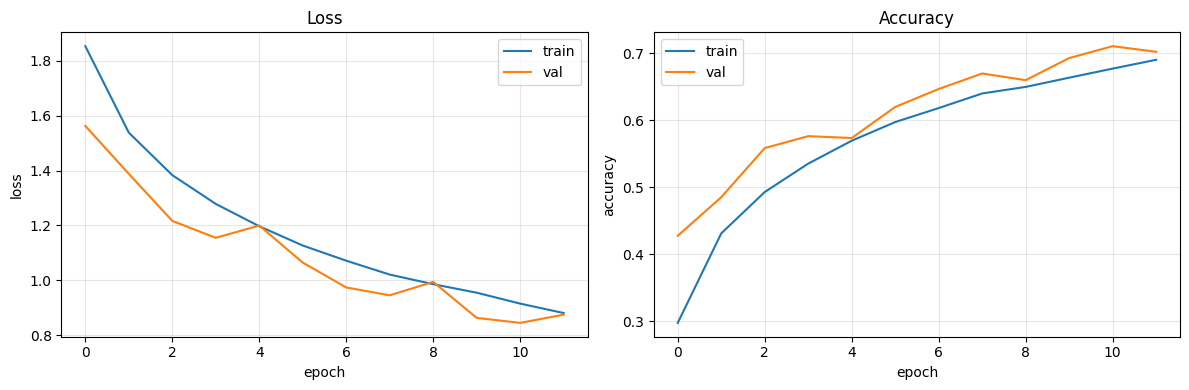

Final test accuracy: 0.710


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Final evaluation on the truly held-out test set (touch this only once!)
test_ds = make_ds(test_images, test_labels)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Final test accuracy: {test_acc:.3f}')


### Bonus: Why is validation curve jumpy and more?

Why val is noisier than train: Train loss is averaged over hundreds of mini-batches per epoch, which smooths out the curve. Val loss is a single measurement computed once at the end of each epoch on a fixed set, so there's no averaging — every wiggle in the weights at that moment shows up directly. Smaller validation sets amplify this.

Why val sits below train: Val being consistently better than train usually means one of:

* Regularization is active during training but off during validation — dropout, weight decay, label smoothing, etc. all make train loss look artificially higher.

* Data augmentation on train only — if you're augmenting (random crops, flips, noise), the train set is effectively harder than val.

* Train loss is averaged across the epoch including the early batches when weights were worse, while val is measured at the end with the improved weights. This effect alone often gives val a ~1 epoch "head start" look.

* Small or easy val set — if it's not representative, it can just happen to be easier.

# Modify and compare

## Variant 1: stride -> MaxPooling

In [15]:
def build_baseline_v1(input_shape=(32, 32, 3), num_classes=10, dropout=0.3):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Block 1: 32x32, 32 filters → 16x16
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    # x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Block 2: 16x16, 64 filters → 8x8
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    # x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Block 3: 8x8, 128 filters → 4x4
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    # x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes)(x)

    return models.Model(inputs, outputs)

model = build_baseline_v1()
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Light data augmentation — helps a lot on small datasets
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
])

def make_ds(x, y, batch=128, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000).map(lambda i, l: (data_aug(i, training=True), l))
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_images, train_labels, training=True)
val_ds   = make_ds(val_images,   val_labels)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=2,
)

Epoch 1/12
391/391 - 42s - 107ms/step - accuracy: 0.2924 - loss: 1.8925 - val_accuracy: 0.4010 - val_loss: 1.6851
Epoch 2/12
391/391 - 40s - 102ms/step - accuracy: 0.3968 - loss: 1.6431 - val_accuracy: 0.4524 - val_loss: 1.5326
Epoch 3/12
391/391 - 41s - 105ms/step - accuracy: 0.4381 - loss: 1.5400 - val_accuracy: 0.5010 - val_loss: 1.3923
Epoch 4/12
391/391 - 41s - 104ms/step - accuracy: 0.4701 - loss: 1.4666 - val_accuracy: 0.5176 - val_loss: 1.3314
Epoch 5/12
391/391 - 40s - 103ms/step - accuracy: 0.4897 - loss: 1.4163 - val_accuracy: 0.5292 - val_loss: 1.2874
Epoch 6/12
391/391 - 39s - 100ms/step - accuracy: 0.5074 - loss: 1.3662 - val_accuracy: 0.5562 - val_loss: 1.2328
Epoch 7/12
391/391 - 40s - 101ms/step - accuracy: 0.5255 - loss: 1.3207 - val_accuracy: 0.5670 - val_loss: 1.2012
Epoch 8/12
391/391 - 39s - 101ms/step - accuracy: 0.5401 - loss: 1.2857 - val_accuracy: 0.5752 - val_loss: 1.1924
Epoch 9/12
391/391 - 40s - 103ms/step - accuracy: 0.5512 - loss: 1.2569 - val_accuracy: 

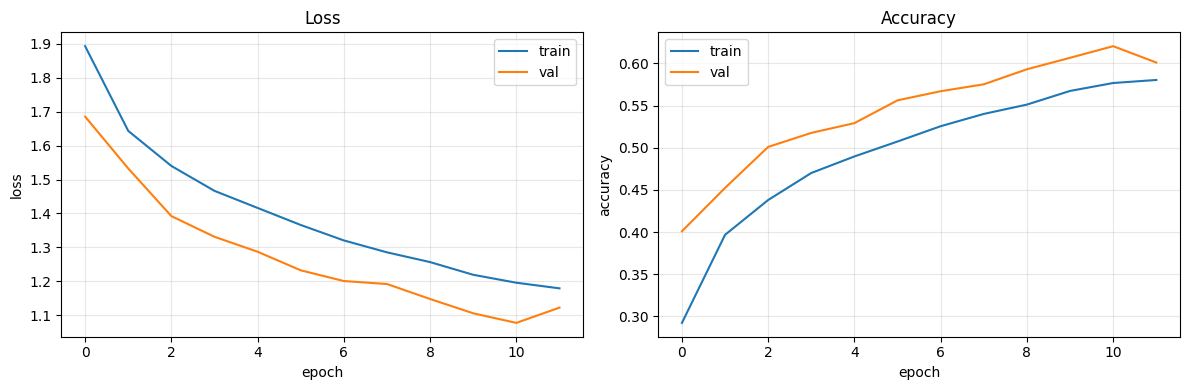

Final test accuracy: 0.615


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Final evaluation on the truly held-out test set (touch this only once!)
test_ds = make_ds(test_images, test_labels)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Final test accuracy: {test_acc:.3f}')

Why does it perform wrose than the baseline model? We used pooling and lost half the depth (MaxPool2D(2)), and a third or learnable parameters. We didn't just downsampled, we were doing a learned downsamplling, extracting features on the way down. MaxPool throws away 3 out of evert 4 activations with a fixed rule.

*   Less depth + less learnable transformation = worse representations = lower accuracy

How come now that validation curve is smoother when we used the same sets?

* A smaller, shallower model has less per-epoch weight movement(fewer parameters = each gradient step changes the overall function less dramatically)
* Lower-capacity models tend to live in flatter regions where sall weight changes don't cause sudden accuracy shifts to the validation set
* No learned downsampling noise (strided convs have learnable weights for the downsampling step itself, which adds more degrees of freedom (and more noise) compared to deterministic MaxPool)


## Variant 2: replace padding='same' with padding='valid'

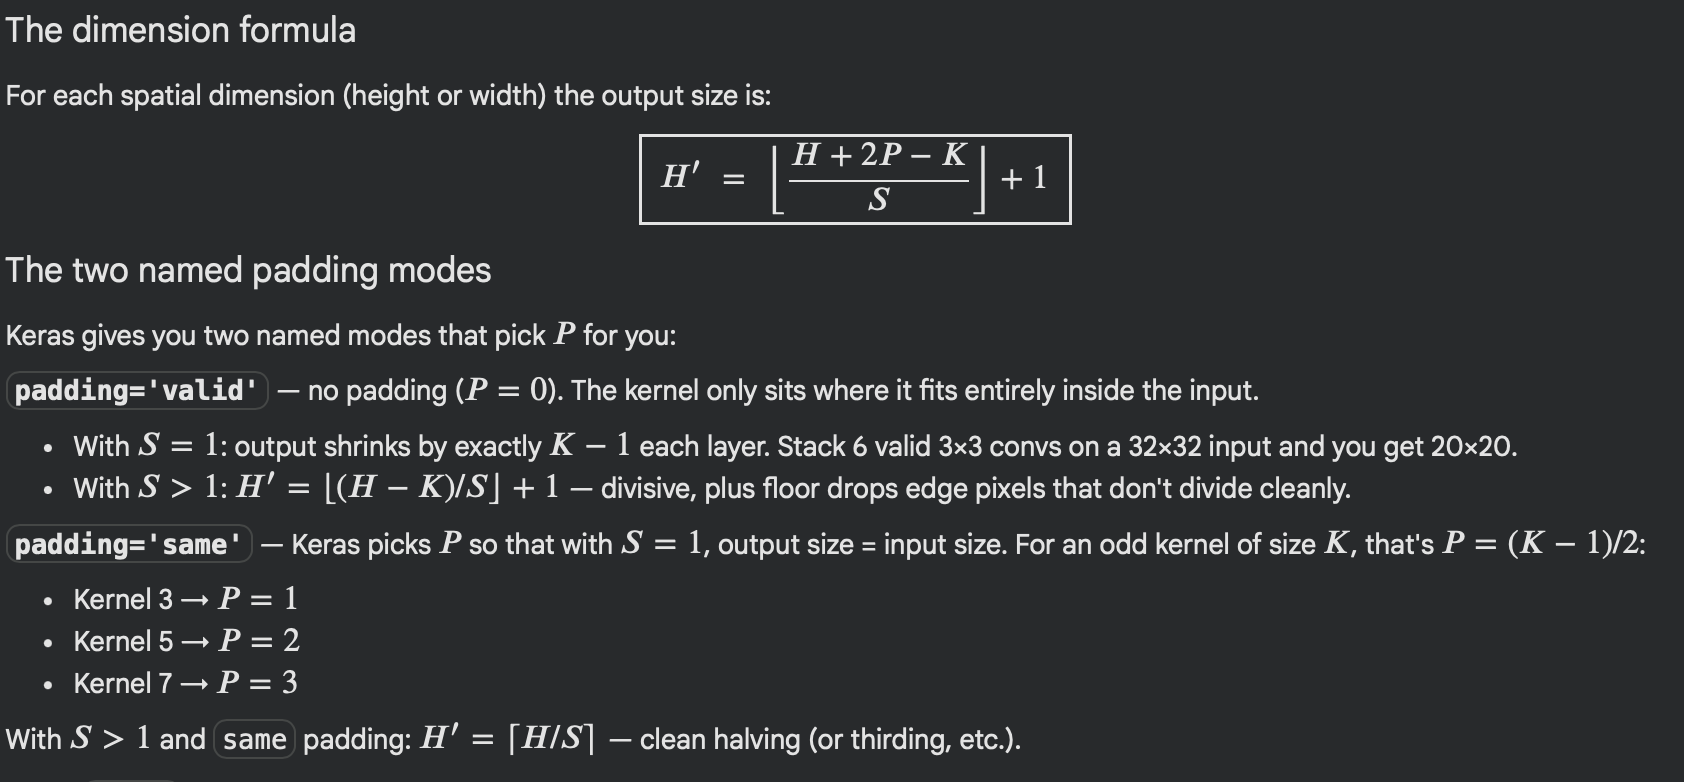

In [18]:
def build_baseline_v2(input_shape=(32, 32, 3), num_classes=10, dropout=0.3):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Block 1: 32x32, 32 filters → 16x16
    x = layers.Conv2D(32, 3, padding='valid', activation='relu')(x) # 30x30
    x = layers.Conv2D(32, 3, strides=2, padding='valid', activation='relu')(x) # 14x14

    # Block 2: 16x16, 64 filters → 8x8
    x = layers.Conv2D(64, 3, padding='valid', activation='relu')(x) # 12x12
    x = layers.Conv2D(64, 3, strides=2, padding='valid', activation='relu')(x) #5x5

    # Block 3: 8x8, 128 filters → 4x4
    x = layers.Conv2D(128, 3, padding='valid', activation='relu')(x) # 3x3
    x = layers.Conv2D(128, 3, strides=2, padding='valid', activation='relu')(x) # 1x1

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes)(x)

    return models.Model(inputs, outputs)

model = build_baseline_v2()
model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 1, 1, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,298 (1.10 MB)

 Trainable params: 288,298 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

The model still works — GAP on a 1×1 input is just identity — but you've completely collapsed spatial information.

If you tried to add a fourth block, the next conv would attempt  𝐾=3  on a  1×1  input -> output size 1+2⋅0−3+1=−1 , which Keras refuses to build. So the architecture works only because we stopped at 3 blocks.

In [19]:
# Light data augmentation — helps a lot on small datasets
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
])

def make_ds(x, y, batch=128, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000).map(lambda i, l: (data_aug(i, training=True), l))
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_images, train_labels, training=True)
val_ds   = make_ds(val_images,   val_labels)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=2,
)


Epoch 1/12
391/391 - 31s - 80ms/step - accuracy: 0.3291 - loss: 1.8038 - val_accuracy: 0.4022 - val_loss: 1.6671
Epoch 2/12
391/391 - 29s - 75ms/step - accuracy: 0.4460 - loss: 1.5125 - val_accuracy: 0.5194 - val_loss: 1.3220
Epoch 3/12
391/391 - 29s - 75ms/step - accuracy: 0.5018 - loss: 1.3785 - val_accuracy: 0.5422 - val_loss: 1.2568
Epoch 4/12
391/391 - 29s - 74ms/step - accuracy: 0.5372 - loss: 1.2865 - val_accuracy: 0.5964 - val_loss: 1.1291
Epoch 5/12
391/391 - 29s - 75ms/step - accuracy: 0.5659 - loss: 1.2203 - val_accuracy: 0.5882 - val_loss: 1.1710
Epoch 6/12
391/391 - 29s - 75ms/step - accuracy: 0.5931 - loss: 1.1532 - val_accuracy: 0.6204 - val_loss: 1.0536
Epoch 7/12
391/391 - 29s - 75ms/step - accuracy: 0.6120 - loss: 1.0979 - val_accuracy: 0.6578 - val_loss: 0.9868
Epoch 8/12
391/391 - 29s - 74ms/step - accuracy: 0.6309 - loss: 1.0554 - val_accuracy: 0.6724 - val_loss: 0.9558
Epoch 9/12
391/391 - 29s - 75ms/step - accuracy: 0.6471 - loss: 1.0100 - val_accuracy: 0.6466 - 

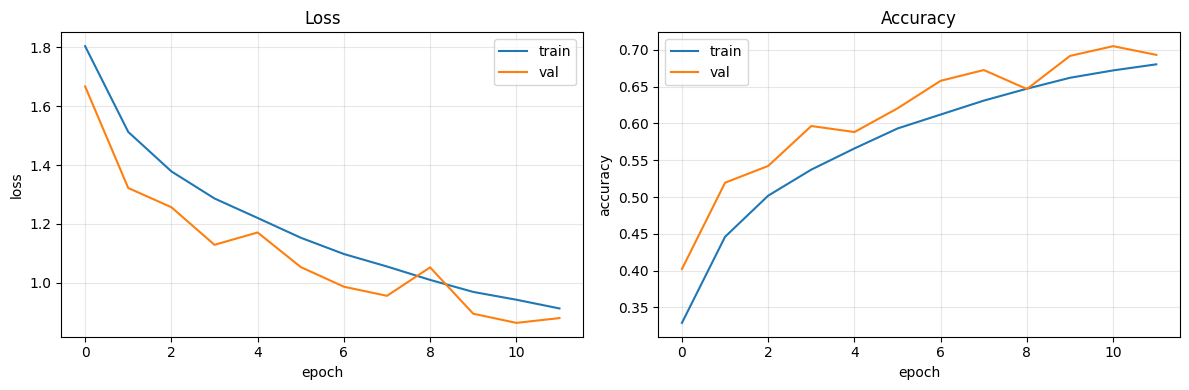

Final test accuracy: 0.709


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Final evaluation on the truly held-out test set (touch this only once!)
test_ds = make_ds(test_images, test_labels)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Final test accuracy: {test_acc:.3f}')

Almost the same as the baseline. Why?

We changed padding='same' -> padding='valid', which only affects how borders are handled and how fast the spatial dims shrink. Everything else is identical:

Same number of conv layers (6)
Same filter counts (32 → 64 → 128)
Essentially the same parameter count (padding doesn't change kernel weights)

So the model's capacity is unchanged. The only real differences are:

* Border pixels get dropped instead of zero-padded. For 32×32 CIFAR images this is a small effect — we lose a 1-pixel ring at each conv layer.
Final feature map is 1×1×128 instead of 4×4×128. This means GlobalAveragePooling2D is basically a no-op in v2 (averaging one value), while in the baseline it averages over 16 spatial positions.

In theory, the baseline's GAP over 16 positions should give a slightly more robust feature vector (more spatial pooling = more translation invariance). In practice with CIFAR-10 at this scale, the difference is within noise — and our plots show that.

What is the difference then with 'padding' and 'valid' in this case?

valid here is a small efficiency win (less compute/memory) and a small information loss (fewer border pixels, no GAP averaging at the end).

In more detail:

Same number of weights, but each weight gets applied fewer times. So v2 trains a bit faster and uses less activation memory — maybe 15–25% less FLOPs overall on this architecture. On CIFAR you won't really notice, but on bigger inputs it adds up.

* No zero-padding artifacts. same padding pads with zeros, so the kernel at the border sees real pixels next to fake zeros. The model has to learn to ignore that. With valid it never sees fake zeros. Real but small effect — usually a fraction of a percent in accuracy, and it can go either way.

* You "lose" the border pixels as a side effect. Each valid conv shaves a 1-pixel ring. With six convs you've essentially thrown away the outer approx. 6 pixels of context. On 32×32 inputs that's a meaningful chunk of the image — most of what GAP averaged over in the baseline was central content anyway, but in principle you have less information to work with.